IDENTITAS : HANI OCTAVIANA RAHAYU


---

**PURPOSE OF THE ANALYSIS**

The goal of this analysis is to build an ANN model that can **predict laptop prices** based on their specs and features — things like brand, laptop type, screen size, RAM, OS, weight, and screen resolution. The model should be able to give a pretty accurate price estimate. Than strealim the model and deploy to github & streamlit.

**DATASET**

The dataset used is the **Laptop Price Dataset**, which contains various laptop specs along with their selling prices in euros. It has both numerical and categorical data. The target variable (y) is **Price_euro**.

---

**KEY QUESTIONS & FINDINGS**

**1. Which feature has the strongest relationship with price?**

  **RAM** has the strongest correlation with laptop price.

**2. How is the data distributed?**

  The data is **not normally distributed** — it's skewed to the right (positively skewed).

**3. How many outliers were there, and did cleaning them up help?**

  There were **a lot of outliers**. After cleaning them up, the model quality improved noticeably.

**4. Which model performed the best, and was there overfitting?**

  ANN performed overfitting, the training score was higher than the test score.

**5. Did ANN perfomed better than Ridge Regression?**

  No, the best perform is Ridge Regression. The reason why is in below. (Part comparing the models)


# Laptop Prices Predict — Model ANN
**Dataset:** Laptop Prices | **Target:** Price_euros

Pipeline:
1. Import Libraries
2. Data Loading
3. Data Cleaning
4. Outlier Removal (IQR)
5. Encoding & Feature Split
6. Train-Test Split
7. Scaling - RobustScaler
8. Build ANN
9. Train ANN
10. Visualization of curve training
11. Model Evaluation
12. Visualization of training results
13. Distribution of error
14. Save model & Download

**Comparing to the project 1 with Ridge Regression model, the results is:**

MAE        : 179.81
RMSE       : 232.50
R² test    : 84,2%
R² Train   : 91,5%



  while for this Artificial Neural Network (ANN), the results is:

MAE        : 239.08
RMSE       : 326.35
R² Test    : 72.5%
R² Train   : 84.2%



  So, the best model for predict laptop price is Ridge Regression based on number metric. But, based on the results, Ridge Regression is the better model.

  Ridge Regression is simpler and easier to understand. For a dataset like laptop prices, it works really well because the relationship between features and price is mostly linear.So there's no need for a complex model.

  The ANN actually shows overfitting, its performed well on training data but not as good on test data. This means the model didn't generalize well enough to new data.

  So Ridge Regression wins here, not just because of better numbers, but because it's more stable and more suitable for this kind of dataset.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print('TensorFlow version:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Load Data

Previously, Kak Ilham gave feedback that the data loading should include a link that's easy for others to access. After exploring more, this was done by **uploading the CSV file to the LaptopApp GitHub repository**. A **raw.githubusercontent** link was then obtained so the file can be read directly in Colab.

In [2]:
url = "https://raw.githubusercontent.com/octavian2810/LaptopPriceApp/main/laptop_prices-selected-columns.csv"

laptop_df = pd.read_csv(url)

laptop_df.head()

,Company,Product,TypeName,Inches,Ram,OS,Weight,Price_euros,Screen,ScreenW
0,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1339.69,Standard,2560
1,Apple,Macbook Air,Ultrabook,13.3,8,macOS,1.34,898.94,Standard,1440
2,HP,250 G6,Notebook,15.6,8,No OS,1.86,575.00,Full HD,1920
3,Apple,MacBook Pro,Ultrabook,15.4,16,macOS,1.83,2537.45,Standard,2880
4,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1803.60,Standard,2560


## 3. Data Cleaning

After loading the data, basic cleaning was done by checking for missing values, verifying data types, listing available columns, counting total rows, and more. In this dataset, duplicate rows were found and removed.

In [3]:
# Info & tipe data
laptop_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1275 entries, 0 to 1274
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Company      1275 non-null   object 
 1   Product      1275 non-null   object 
 2   TypeName     1275 non-null   object 
 3   Inches       1275 non-null   float64
 4   Ram          1275 non-null   int64  
 5   OS           1275 non-null   object 
 6   Weight       1275 non-null   float64
 7   Price_euros  1275 non-null   float64
 8   Screen       1275 non-null   object 
 9   ScreenW      1275 non-null   int64  
dtypes: float64(3), int64(2), object(5)
memory usage: 99.7+ KB


In [4]:
# Missing values
print('Missing values:')
print(laptop_df.isnull().sum())

Missing values:
Company        0
Product        0
TypeName       0
Inches         0
Ram            0
OS             0
Weight         0
Price_euros    0
Screen         0
ScreenW        0
dtype: int64


In [5]:
# Hapus duplikat
print(f'Duplikat: {laptop_df.duplicated().sum()}')
laptop_df.drop_duplicates(inplace=True)
print(f'Shape setelah drop duplikat: {laptop_df.shape}')

Duplikat: 2
Shape setelah drop duplikat: (1273, 10)


This step explores the **statistical distribution** of the laptop price dataset, including mean, median, standard deviation, and more.

In [6]:
laptop_df .describe()

,Inches,Ram,Weight,Price_euros,ScreenW
count,1273.000000,1273.000000,1273.000000,1273.000000,1273.000000
mean,15.020660,8.444619,2.039804,1135.586449,1900.012569
std,1.429074,5.100279,0.669368,700.997860,493.733250
min,10.100000,2.000000,0.690000,174.000000,1366.000000
25%,14.000000,4.000000,1.500000,609.000000,1920.000000
50%,15.600000,8.000000,2.040000,989.000000,1920.000000
75%,15.600000,8.000000,2.310000,1498.000000,1920.000000
max,18.400000,64.000000,4.700000,6099.000000,3840.000000


Cause the target variable in this model is laptop price, a histogram of the Price_euros distribution was created.

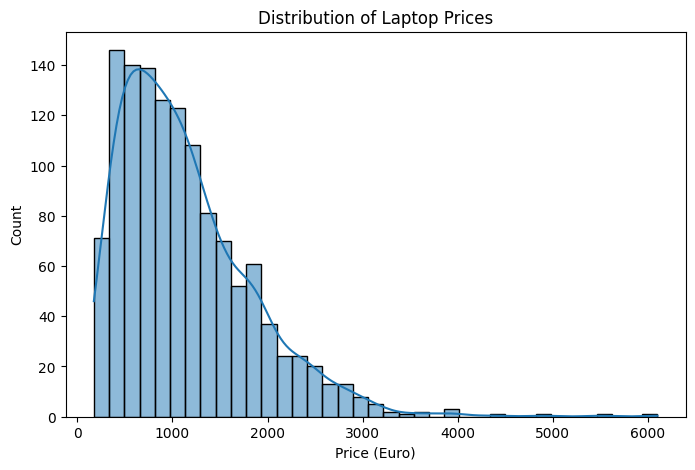

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(laptop_df['Price_euros'], kde=True)

plt.title('Distribution of Laptop Prices')
plt.xlabel('Price (Euro)')
plt.show()

Just like in Project 1, the distribution is skewed to the right (positively skewed).

## 4. Outlier Removal (IQR / Tukey)
- RAM and ScreenW were kept — these are discrete specs, not outliers or incorrect data.
- Inches, Weight, and Price_euros were cleaned.

In [8]:
cat_cols = ['Company', 'Product', 'TypeName', 'OS', 'Screen']

num_cols = ['Inches', 'Ram', 'Weight', 'Price_euros', 'ScreenW']

print(f'Kolom kategorikal: {cat_cols}')
print(f'Kolom numerikal: {num_cols}')

Kolom kategorikal: ['Company', 'Product', 'TypeName', 'OS', 'Screen']
Kolom numerikal: ['Inches', 'Ram', 'Weight', 'Price_euros', 'ScreenW']


In [9]:
#Mencari outlier menggunakan Tukey rule
num_cols = ['Inches', 'Ram', 'Weight', 'Price_euros', 'ScreenW']

for col in num_cols:
    Q1 = laptop_df[col].quantile(0.25)
    Q3 = laptop_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = laptop_df[
        (laptop_df[col] < lower_bound) |
        (laptop_df[col] > upper_bound)
    ]

    print(f"{col}: {len(outliers)} outlier")

Inches: 37 outlier
Ram: 219 outlier
Weight: 45 outlier
Price_euros: 28 outlier
ScreenW: 437 outlier


In [ ]:
Many outliers were detected, with the most found in the RAM and ScreenW columns.

Since RAM and ScreenW are actual specs and not outliers that need to be removed, outlier cleaning was only applied to the following columns.

In [10]:
cols_to_clean = ['Inches', 'Weight', 'Price_euros']

print("=== MENCARI DAN MEMBERSIHKAN OUTLIER (TUKEY/IQR) ===")

for col in cols_to_clean:

        Q1 = laptop_df[col].quantile(0.25)
        Q3 = laptop_df[col].quantile(0.75)
        IQR = Q3 - Q1

        low_bound = Q1 - 1.5 * IQR
        up_bound = Q3 + 1.5 * IQR

        total_rows = len(laptop_df)


        outlier_mask = (laptop_df[col] < low_bound) | (laptop_df[col] > up_bound)
        num_outliers = outlier_mask.sum()
        keep_mask = ~outlier_mask


        df_clean = laptop_df[keep_mask]


        print(f'Atribut: {col}')
        print(f'Q1: {Q1:.2f}')
        print(f'Q3: {Q3:.2f}')
        print(f'IQR: {IQR:.2f}')
        print(f'Upper Boundary: {up_bound:.2f}')
        print(f'Lower Boundary: {low_bound:.2f}')
        print(f'Jumlah Outlier: {num_outliers}')
        print(f'Percentage of outliers: {(num_outliers * 100 / total_rows):.2f}%')
        print('=' * 50)

=== MENCARI DAN MEMBERSIHKAN OUTLIER (TUKEY/IQR) ===
Atribut: Inches
Q1: 14.00
Q3: 15.60
IQR: 1.60
Upper Boundary: 18.00
Lower Boundary: 11.60
Jumlah Outlier: 37
Percentage of outliers: 2.91%
Atribut: Weight
Q1: 1.50
Q3: 2.31
IQR: 0.81
Upper Boundary: 3.53
Lower Boundary: 0.28
Jumlah Outlier: 45
Percentage of outliers: 3.53%
Atribut: Price_euros
Q1: 609.00
Q3: 1498.00
IQR: 889.00
Upper Boundary: 2831.50
Lower Boundary: -724.50
Jumlah Outlier: 28
Percentage of outliers: 2.20%


## 5. Encoding & Feature Split

Encode categorical columns with One-Hot Encoder

In [11]:
cat_cols = ['Company', 'Product', 'TypeName', 'OS', 'Screen']
num_cols = ['Inches', 'Ram', 'Weight', 'ScreenW']

# Pisah X dan y
X = df_clean.drop('Price_euros', axis=1)
y = df_clean['Price_euros']

# One-Hot Encoding pada kolom kategorikal
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print(f'Shape X setelah encoding: {X_encoded.shape}')
print(f'Jumlah fitur: {X_encoded.shape[1]}')
X_encoded.head()

Shape X setelah encoding: (1245, 644)
Jumlah fitur: 644


,Inches,Ram,Weight,ScreenW,Company_Apple,Company_Asus,Company_Chuwi,Company_Dell,Company_Fujitsu,Company_Google,...,OS_Linux,OS_Mac OS X,OS_No OS,OS_Windows 10,OS_Windows 10 S,OS_Windows 7,OS_macOS,Screen_Full HD,Screen_Quad HD+,Screen_Standard
0,13.3,8,1.37,2560,True,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
1,13.3,8,1.34,1440,True,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
2,15.6,8,1.86,1920,False,False,False,False,False,False,...,False,False,True,False,False,False,False,True,False,False
3,15.4,16,1.83,2880,True,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
4,13.3,8,1.37,2560,True,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True


## 6. Train-Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    random_state=42
)

print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')
print(f'y_train : {y_train.shape}')
print(f'y_test  : {y_test.shape}')

X_train : (996, 644)
X_test  : (249, 644)
y_train : (996,)
y_test  : (249,)


## 7. Scaling — RobustScaler
> Dipilih karena data skewed & masih ada outlier pada Ram dan ScreenW

In [13]:
scaler = RobustScaler()

X_train_sc = scaler.fit_transform(X_train)  # fit HANYA pada train
X_test_sc  = scaler.transform(X_test)       # transform test pakai parameter train

print('Scaling selesai.')
print(f'X_train_sc shape: {X_train_sc.shape}')

Scaling selesai.
X_train_sc shape: (996, 644)


## 8. Build Model ANN
Only 2 hidden layers for small dataset. In this case, I use the dataset that only have 1275 data. So, no need to use more than 2 hiddn layers.

Dense for hidden layer 1 is 16 neurons and for hidden layer 2 is 8 neurons. As my knowledge and convention in this case, used multiples of 8 is the best decision to choose.

So, the parameter on the hidden layer 1 is 16 x 644 + 16 = 10.320

Activation default use relu for hidden layer 1 and 2, and sigmoid for output. Cause I think this activation is commonly used for small dataset.

In this case, BatchNormalization used for stabilize and speed up the neural network training process. BatchNormalization means, normalize the output first before droupout and enter the next hidden layer.

Dropout : Non-activate 30% and 20% neuron, so the model doesn't memorize the data.

And compile the model with Adam for opimize this training. This the best and commonly used for training small dataset with learning rate 0.001, this is default.

Why did I choose MSE for loss and MAE for metric?
Cause MSE is match for regression and the best metric for optimation process. MAE easier to interpret as the average of the difference between  actual value and predicted value.

In [37]:
tf.random.set_seed(42)

n_features = X_train_sc.shape[1]

model = keras.Sequential([
    layers.Input(shape=(n_features,)),

    # Hidden Layer 1
    layers.Dense(16, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    # Hidden Layer 2
    layers.Dense(8, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    # Output
    layers.Dense(1, activation='sigmoid'),
], name='ANN_LaptopPrice')

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "ANN_LaptopPrice"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 16)             │        10,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 8)              │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,561 (41.25 KB)

 Trainable params: 10,513 (41.07 KB)

 Non-trainable params: 48 (192.00 B)

## 9. Training

Train the data after scaling with 150 epoch and 32 for batch size because thi is the better than others training with various size for epoch and batch size.

Till reach 131 epoch, the training was stopping cause for this training use callback EarlyStopping.

15% of data splitting from training used for Validation.



In [38]:
callbacks_list = [
    # Stop if val_loss doesn't improve till reach 25 epoch
    EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True, verbose=1),

    # Decrease learning rate if stagnan
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1)
]

history = model.fit(
    X_train_sc, y_train,
    epochs=150,
    batch_size=32,
    validation_split=0.15,
    callbacks=callbacks_list,
    verbose=1
)

Epoch 1/150
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - loss: 1495838.2500 - mae: 1075.4047 - val_loss: 1779478.6250 - val_mae: 1169.6981 - learning_rate: 0.0010
Epoch 2/150
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1495736.1250 - mae: 1075.3777 - val_loss: 1779438.8750 - val_mae: 1169.7013 - learning_rate: 0.0010
Epoch 3/150
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1495603.1250 - mae: 1075.3464 - val_loss: 1779266.3750 - val_mae: 1169.6228 - learning_rate: 0.0010
Epoch 4/150
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1495514.5000 - mae: 1075.3291 - val_loss: 1779225.8750 - val_mae: 1169.5848 - learning_rate: 0.0010
Epoch 5/150
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1495496.1250 - mae: 1075.2871 - val_loss: 1779096.7500 - val_mae: 1169.5255 - learning_rate: 0.0010
Epoch 6/150
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1495411.7500 - mae: 1075.2615 - val_loss: 1778830.0000 - val_mae: 1169.4474 - learning_rate: 0.0010
Epoch 7/150
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms

## 10. Visualisasi Kurva Training

This is the curve visualization error of ANN model training with the best result, this curve showing the training is goodfit. But, again... this is just assume From visualization, we know that if the line of train and validation is decrease concurrent and closely.It means, the error and rate of missing prediction is small.

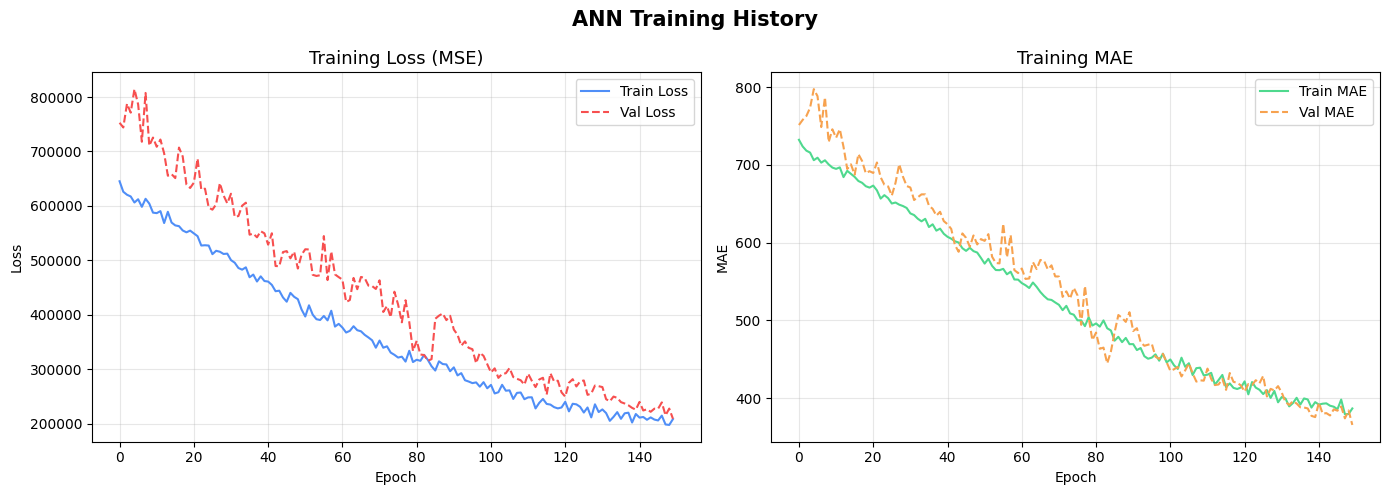

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'],     label='Train Loss', color='#4f8ef7')
axes[0].plot(history.history['val_loss'], label='Val Loss',   color='#f74f4f', linestyle='--')
axes[0].set_title('Training Loss (MSE)', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE
axes[1].plot(history.history['mae'],     label='Train MAE', color='#4fd98e')
axes[1].plot(history.history['val_mae'], label='Val MAE',   color='#f7a24f', linestyle='--')
axes[1].set_title('Training MAE', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('ANN Training History', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Evaluasi Model

The results of error or rate of missing prediction in this training is:
MAE        : 239.08
RMSE       : 326.35

And rate of successful read variances is 72.5% on the test set, 84.2% on the train set. So, from the gap this training is little bit overfitting.

In [21]:
# Prediction
y_pred       = model.predict(X_test_sc).flatten()
y_train_pred = model.predict(X_train_sc).flatten()

# Test metric
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

# R² Train
r2_train = r2_score(y_train, y_train_pred)

print('=' * 40)
print('         EVALUASI MODEL ANN')
print('=' * 40)
print(f'MAE        : {mae:.2f}')
print(f'RMSE       : {rmse:.2f}')
print(f'R² Test    : {r2:.4f}  ({r2*100:.1f}%)')
print(f'R² Train   : {r2_train:.4f}  ({r2_train*100:.1f}%)')
print(f'Gap (overfit): {r2_train - r2:.4f}')
print('=' * 40)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
         EVALUASI MODEL ANN
MAE        : 239.08
RMSE       : 326.35
R² Test    : 0.7248  (72.5%)
R² Train   : 0.8417  (84.2%)
Gap (overfit): 0.1169


## 12. Visualisasi Hasil Prediksi

The model can explain approximately 72.5% of the variance in laptop prices. Most predictions are close to the actual values, as shown by the clustering of points around the ideal line. The residuals are centered around zero, suggesting that the model doesn't exhibit significant prediction bias.


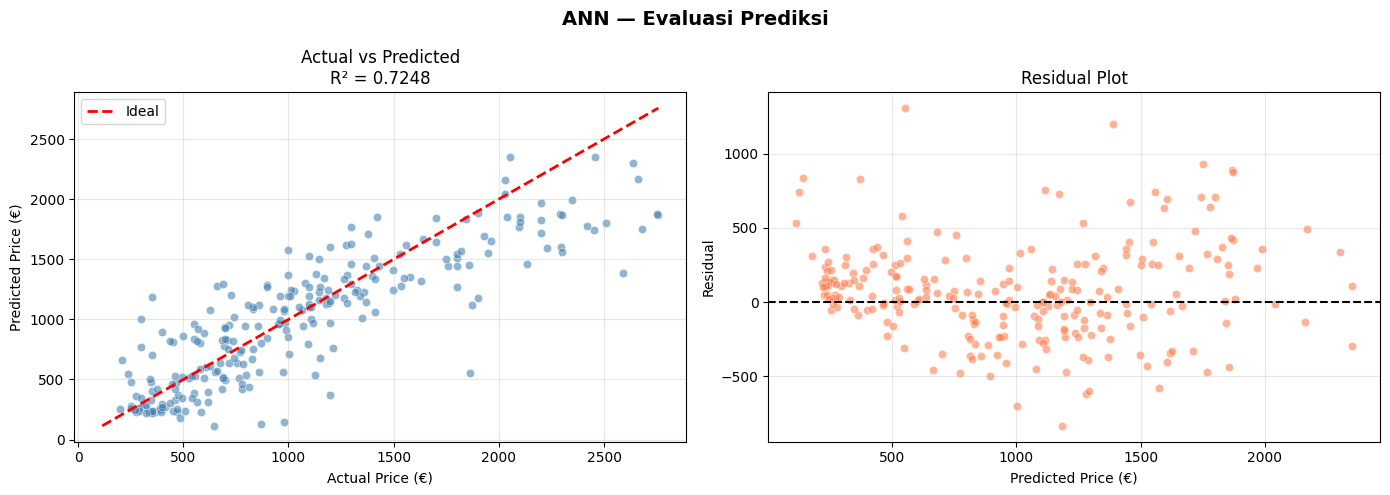

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Actual vs Predicted ---
axes[0].scatter(y_test, y_pred, alpha=0.6, color='steelblue', edgecolors='white', linewidth=0.5)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', linewidth=2, label='Ideal')
axes[0].set_xlabel('Actual Price (€)')
axes[0].set_ylabel('Predicted Price (€)')
axes[0].set_title(f'Actual vs Predicted\nR² = {r2:.4f}', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Plot 2: Residual ---
residuals = np.array(y_test) - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.6, color='coral', edgecolors='white', linewidth=0.5)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Predicted Price (€)')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.suptitle('ANN — Evaluasi Prediksi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 13. Distribusi Error

Most errors are close to zero, which means the model predictions are generally good. However, the graph is slightly skewed to the right, meaning the model sometimes underpredicts the actual values.

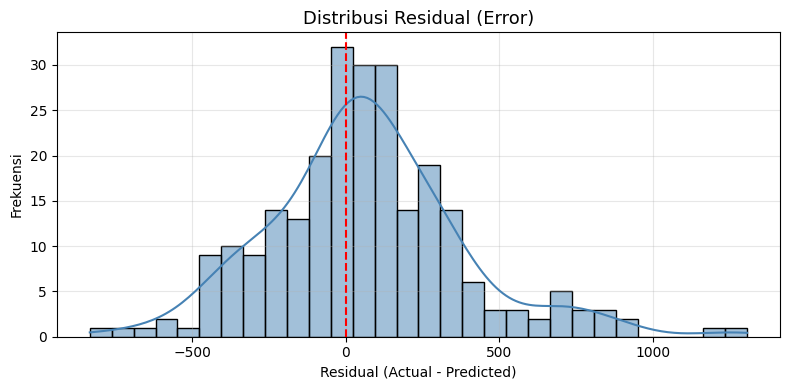

Mean error  : 67.03
Std error   : 319.40


In [24]:
plt.figure(figsize=(8, 4))
sns.histplot(residuals, kde=True, color='steelblue', bins=30)
plt.axvline(0, color='red', linestyle='--', linewidth=1.5)
plt.title('Distribusi Residual (Error)', fontsize=13)
plt.xlabel('Residual (Actual - Predicted)')
plt.ylabel('Frekuensi')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Mean error  : {residuals.mean():.2f}')
print(f'Std error   : {residuals.std():.2f}')

## 14. Save Model & Download

Save artifact of model ANN for deployment app. This step produce 3 file model; ann_model.keras, feature_columns.pkl, scaler.pkl

In [25]:
import os

os.makedirs("models", exist_ok=True)
model.save("models/ann_model.keras")

In [26]:
# from google.colab import files

# files.download("models/ann_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
import pickle
import os
import joblib

os.makedirs("models", exist_ok=True)

feature_columns = X_train.columns.tolist()

with open("models/feature_columns.pkl", "wb") as f:
    pickle.dump(feature_columns, f)

joblib.dump(scaler, "models/scaler.pkl")

['models/scaler.pkl']

In [28]:
!ls -lh models

total 2.6M
-rw-r--r-- 1 root root 2.5M Jun 24 06:53 ann_model.keras
-rw-r--r-- 1 root root  19K Jun 24 06:53 feature_columns.pkl
-rw-r--r-- 1 root root  30K Jun 24 06:53 scaler.pkl


In [29]:
# from google.colab import files

# files.download("models/feature_columns.pkl")
# files.download("models/scaler.pkl")